In [140]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm
step_size = 0.01
planets = np.array([[-1, 0], [1, 0]])

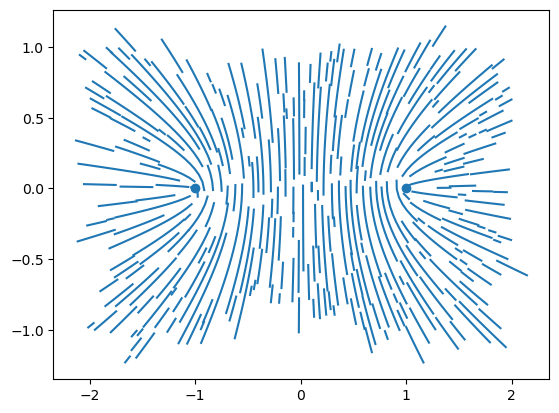

In [150]:
# Jobard & Lefer algo
min_dist = 0.05
step_size = 0.06
def get_force(pos) -> tuple[np.array, bool]:
    force = np.array([0., 0.])
    for y,planet in enumerate(planets):
        u = normalize(planet-pos)
        d_squared = u.dot(u)
        if d_squared<0.01:
            return True
        # Make simple plus and minus poles
        # if y==0:
        #     u = -u
        force = force+1./d_squared*u
    return (force, False)

def retrieve_line(start_pos, n=50) -> np.array:
    pos = np.array(start_pos)
    points = [pos, ]
    
    done = False
    for j in range(n):
        force, done = get_force(pos)
        if done or (force == np.array([0., 0.])).all():break
        pos = pos+(normalize(force)*step_size)

        # Check if no near-points:
        has_near = False
        for all_p in all_points:
            d = all_p-pos
            if np.linalg.norm(d)<min_dist:
                has_near = True
                break
        if has_near: break

        points.append(pos)
        all_points.append(pos)
    return np.array(points)

def draw_and_retrieve(*args, **kwargs):
    l = retrieve_line(*args, **kwargs)
    ax.add_line(Line2D(l[:, 0], l[:, 1]))
    return l

fig, ax = plt.subplots()
all_points = []

n_iters = 300
for i in range(n_iters):
    rnd_start = np.random.rand(2)*np.array([4., 2.])-np.array([2, 1]) # [-2, -0.5+(i/10)]
    points = draw_and_retrieve(rnd_start, n=100)
    for (k,new_starts) in enumerate(points):
        # if k%2==0:continue
        l2 = draw_and_retrieve(new_starts+np.array([min_dist*np.random.randint(-5, 5), min_dist*np.random.randint(-5, 5)]))
    
    if i%(n_iters/100)==0:
        perc = i/(n_iters/100)
        print(f"{perc}/100", end="\r")

ax.scatter(planets[:, 0], planets[:, 1])
plt.show()

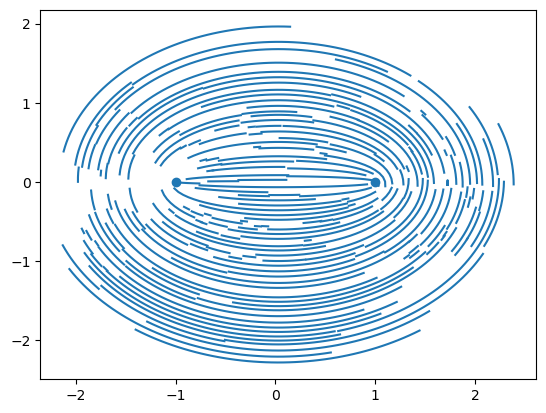

In [151]:
def get_force(pos) -> tuple[np.array, bool]:
    force = np.array([0., 0.])
    for y,planet in enumerate(planets):
        u = normalize(planet-pos)
        d_squared = u.dot(u)
        if d_squared<0.01:
            return True
        # Make simple plus and minus poles
        if y==0:
            u = -u
        force = force+1./d_squared*u
    return (force, False)

# step_size = 0.1
fig, ax = plt.subplots()
all_points = []
n_iters = 300
for i in range(n_iters):
    rnd_start = np.random.rand(2)*np.array([4., 2.])-np.array([2, 1])
    points = draw_and_retrieve(rnd_start) # [-2, -0.5+(i/10)]
    for (k,new_starts) in enumerate(points):
        if k%2==0:continue
        l2 = draw_and_retrieve(new_starts+np.array([min_dist*np.random.randint(-5, 5), min_dist*np.random.randint(-5, 5)]))
    
    if i%(n_iters/100)==0:
        perc = i/(n_iters/100)
        print(f"{perc}/100", end="\r")

ax.scatter(planets[:, 0], planets[:, 1])
plt.show()

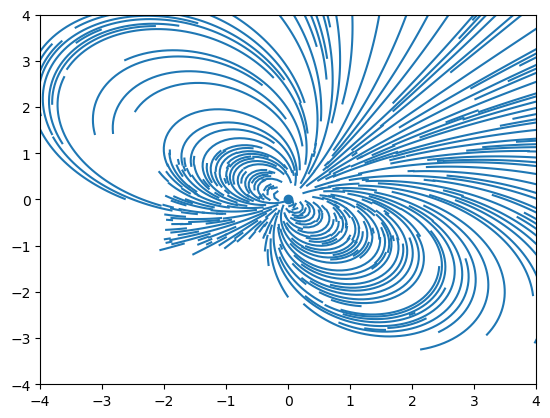

In [160]:
min_dist = 0.05
step_size = 0.08
def get_magnetic_field(pos_particle, pos_magnet, m_vector):
    r_vec = pos_particle - pos_magnet
    r_mag = np.linalg.norm(r_vec)
    
    if r_mag < min_dist/5: return np.array([0.0, 0.0])

    m_dot_r = np.dot(m_vector, r_vec)

    term1 = 3.0 * r_vec * m_dot_r / (r_mag**2)
    term2 = m_vector
    
    B = (term1 - term2) / (r_mag**3)
    return B
def get_force(pos):
    return (get_magnetic_field(pos, np.array([0., 0.]), np.array([1., 1.])), False)

fig, ax = plt.subplots()
all_points = []
n_iters = 400 # This takes ~20seconds at 100 iterations and >1min at 300
for i in range(n_iters):
    rnd_start = np.random.rand(2)*np.array([4., 2.])-np.array([2., 1.])
    points = draw_and_retrieve(rnd_start, n=100) # [-2, -0.5+(i/10)]
    for (k,new_starts) in enumerate(points):
        if k%2==0:continue
        l2 = draw_and_retrieve(new_starts+np.array([min_dist*np.random.randint(-5, 5), min_dist*np.random.randint(-5, 5)]))
    
    if i%(n_iters/100)==0:
        perc = i/(n_iters/100)
        print(f"{perc}/100", end="\r")

ax.scatter(np.array([0.,]), np.array([0., ]))
ax.set(xlim=(-4, 4), ylim=(-4, 4))

plt.show()

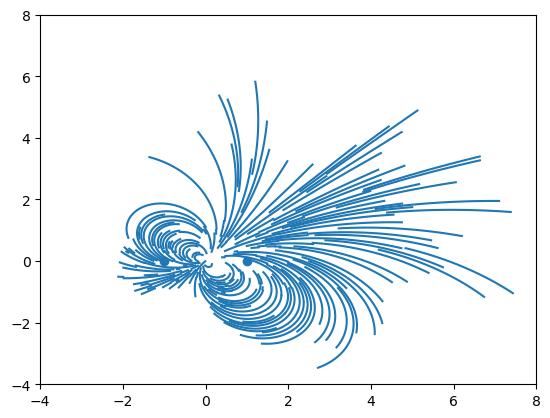

In [135]:
# ax.set_xlim(-4, 8)
# ax.set_ylim(-4, 8)
ax.set_xlim(auto=True)
ax.set_ylim(auto=True)
ax.set_autoscale_on(True)
display(fig)

[(-4.0, 4.0), (-4.0, 4.0)]

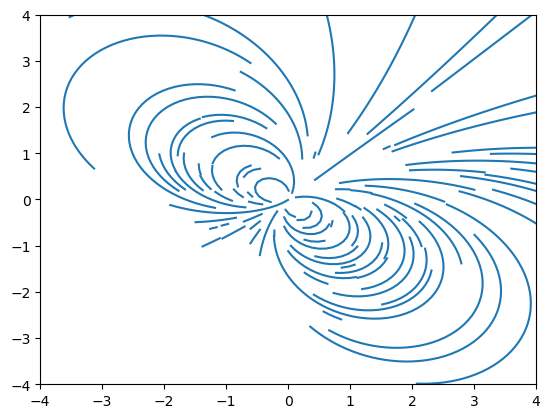

In [ ]:
min_dist = 0.1
step_size = 0.11

def retrieve_line(start_pos, n=50) -> np.array:
    pos = np.array(start_pos)
    points = [pos, ]
    
    for j in range(n):
        force = get_magnetic_field(pos, np.array([0., 0.]), np.array([1., 1.]))
        if (force == np.array([0., 0.])).all(): break
        pos = pos+(force/np.linalg.vector_norm(force)*step_size)

        # Check if no near-points:
        has_near = False
        for all_p in all_points:
            d = all_p-pos
            if np.linalg.vector_norm(d)<min_dist:
                has_near = True
                break
        
        if has_near: break

        points.append(pos)
        all_points.append(pos)
    return np.array(points)

fig_magnetic_01, ax = plt.subplots()
all_points = []
n_iters = 100
for i in range(n_iters):
    rnd_start = np.random.rand(2)*np.array([4., 2.])-np.array([2, 1])
    points = draw_and_retrieve(rnd_start, n=50) # [-2, -0.5+(i/10)]
    for (k,new_starts) in enumerate(points):
        if k%3<=1:continue
        l2 = draw_and_retrieve(new_starts+np.array([min_dist*np.random.randint(-5, 5), min_dist*np.random.randint(-5, 5)]))
    
    if i%(n_iters/100)==0:
        perc = i/(n_iters/100)
        print(f"{perc}/100", end="\r")

ax.set(xlim=(-4, 4), ylim=(-4, 4))

In [115]:
plt.show()